# TPCRP Modification: Cluster-Weighted Selection (TPCRP-CW)

## Motivation

In the original TPCRP algorithm, when multiple clusters share the fewest labeled points, the tiebreaker selects the **largest** cluster. This ignores the quality of the cluster, a large but diffuse cluster may be less informative than a smaller, tightly packed one.

## The Modification

**TPCRP-CW** replaces the largest-cluster tiebreaker with a **cluster score**:

$$\text{score}(c) = |c| \times \overline{\text{typicality}}(c)$$

where $|c|$ is the cluster size and $\overline{\text{typicality}}(c)$ is the mean intra-cluster typicality. This favours clusters that are both large and have high internal typicality, while still prioritising clusters with fewer labeled points as the primary criterion.

All other steps remain identical to the faithful reproduction. Original TPCRP and Random baseline results are loaded from the eval notebook. Only TPCRP-CW is re-run here across Framework 1 (fully supervised) and Framework 2 (linear probe).

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
from tqdm import tqdm
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load embeddings from training notebook
embeddings = np.load('embeddings.npy')
labels     = np.load('labels.npy')
print(f"Embeddings: {embeddings.shape}, Labels: {labels.shape}")

# Load F1 baselines from eval notebook
all_orig = np.load('tpcrp_accuracies.npy')
all_rand = np.load('random_accuracies.npy')
print(f"F1 Original mean: {all_orig.mean(axis=0).round(2)}")
print(f"F1 Random mean:   {all_rand.mean(axis=0).round(2)}")

# Load F2 baselines from eval notebook
lp_orig = np.load('tpcrp_lp_accuracies.npy')
lp_rand = np.load('random_lp_accuracies.npy')
print(f"F2 Original mean: {lp_orig.mean(axis=0).round(2)}")
print(f"F2 Random mean:   {lp_rand.mean(axis=0).round(2)}")

# Datasets and loaders
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.4914, 0.4822, 0.4465],
                         [0.2023, 0.1994, 0.2010])
])
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.4914, 0.4822, 0.4465],
                         [0.2023, 0.1994, 0.2010])
])

train_dataset = datasets.CIFAR10(root='./data', train=True,
                                  download=False, transform=train_transform)
test_dataset  = datasets.CIFAR10(root='./data', train=False,
                                  download=False, transform=test_transform)
test_loader   = DataLoader(test_dataset, batch_size=256,
                           shuffle=False, num_workers=2)
print("Data ready.")

Embeddings: (50000, 512), Labels: (50000,)
F1 Original mean: [13.44 17.92 21.37 22.69 25.81]
F1 Random mean:   [13.69 16.11 18.7  18.14 20.31]
F2 Original mean: [44.74 58.88 65.55 68.45 70.23]
F2 Random mean:   [40.32 49.12 53.36 56.31 59.77]
Data ready.


## TPCRP-CW Selection

Same greedy iterative selection as the faithful reproduction, with one change: when multiple clusters tie for fewest labeled points, instead of picking the largest cluster, we pick the cluster with the highest score = size × mean intra-cluster typicality. Clusters with fewer than 5 points are still dropped, and typicality is computed within each cluster using K=min(20, cluster_size−1) neighbours.

In [3]:
def compute_typicality(cluster_embeddings):
    n = len(cluster_embeddings)
    k = min(20, n - 1)
    if k < 1:
        return np.ones(n)
    nbrs = NearestNeighbors(n_neighbors=k + 1, metric='euclidean')
    nbrs.fit(cluster_embeddings)
    distances, _ = nbrs.kneighbors(cluster_embeddings)
    avg_dist = distances[:, 1:].mean(axis=1)
    return 1.0 / (avg_dist + 1e-8)


def tpcrp_cw_select(embeddings, budget, labeled_indices=None, max_clusters=500):
    """
    TPCRP-CW: Cluster-Weighted selection.
    Modification: tiebreaker uses cluster_score = size * mean_typicality
    instead of largest cluster size.
    """
    if labeled_indices is None:
        labeled_indices = []

    labeled_set = set(labeled_indices)
    n_labeled = len(labeled_indices)
    n_clusters = min(n_labeled + budget, max_clusters)

    if n_clusters <= 50:
        kmeans = KMeans(n_clusters=n_clusters, n_init=10)
    else:
        kmeans = MiniBatchKMeans(n_clusters=n_clusters, n_init=10, batch_size=5000)

    cluster_assignments = kmeans.fit_predict(embeddings)

    # Build cluster-to-indices mapping
    cluster_to_indices = {}
    for idx in range(len(embeddings)):
        c = cluster_assignments[idx]
        if c not in cluster_to_indices:
            cluster_to_indices[c] = []
        cluster_to_indices[c].append(idx)

    # Count labeled points per cluster
    cluster_label_counts = {}
    for idx in labeled_indices:
        c = cluster_assignments[idx]
        cluster_label_counts[c] = cluster_label_counts.get(c, 0) + 1

    # Pre-compute mean typicality per cluster (for tiebreaking)
    cluster_mean_typ = {}
    for c, indices in cluster_to_indices.items():
        if len(indices) <= 5:
            continue
        typ = compute_typicality(embeddings[indices])
        cluster_mean_typ[c] = typ.mean()

    selected = []

    for _ in range(budget):
        best_cluster = None
        fewest_labels = float('inf')
        best_score = -1

        for c, indices in cluster_to_indices.items():
            if len(indices) <= 5 or c not in cluster_mean_typ:
                continue

            n_labeled_in_c = cluster_label_counts.get(c, 0)
            # CW score: size * mean typicality
            score = len(indices) * cluster_mean_typ[c]

            if (n_labeled_in_c < fewest_labels or
                (n_labeled_in_c == fewest_labels and score > best_score)):
                best_cluster = c
                fewest_labels = n_labeled_in_c
                best_score = score

        if best_cluster is None:
            break

        # Select most typical unlabeled point from chosen cluster
        cluster_indices = cluster_to_indices[best_cluster]
        cluster_typ = compute_typicality(embeddings[cluster_indices])

        sorted_by_typ = np.argsort(-cluster_typ)
        for rank in sorted_by_typ:
            idx = cluster_indices[rank]
            if idx not in labeled_set and idx not in selected:
                selected.append(idx)
                break

        cluster_label_counts[best_cluster] = cluster_label_counts.get(best_cluster, 0) + 1

    return np.array(selected)

print("TPCRP-CW defined.")

TPCRP-CW defined.


## Framework 1: Fully Supervised TPCRP-CW Evaluation

In [4]:
def train_classifier(train_indices, test_loader, device, epochs=100):
    labeled_dataset = Subset(train_dataset, train_indices)
    labeled_loader  = DataLoader(labeled_dataset, batch_size=32,
                                 shuffle=True, num_workers=0)

    classifier = models.resnet18(weights=None)
    classifier.fc = nn.Linear(512, 10)
    classifier = classifier.to(device)

    optimizer = optim.SGD(classifier.parameters(), lr=0.025,
                          momentum=0.9, nesterov=True)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()

    classifier.train()
    for epoch in range(epochs):
        for imgs, targets in labeled_loader:
            imgs, targets = imgs.to(device), targets.to(device)
            optimizer.zero_grad()
            loss = criterion(classifier(imgs), targets)
            loss.backward()
            optimizer.step()
        scheduler.step()

    classifier.eval()
    correct = total = 0
    with torch.no_grad():
        for imgs, targets in test_loader:
            imgs, targets = imgs.to(device), targets.to(device)
            _, pred = classifier(imgs).max(1)
            correct += pred.eq(targets).sum().item()
            total   += targets.size(0)
    return 100. * correct / total


N_REPS = 10
BUDGET = 10
all_cw = []

for rep in range(N_REPS):
    print(f"\nRep {rep+1}/{N_REPS}")
    cw_idx, cw_accs = [], []

    for r in range(5):
        new = tpcrp_cw_select(embeddings, BUDGET,
                              labeled_indices=np.array(cw_idx) if cw_idx else None)
        cw_idx.extend(new.tolist())
        acc = train_classifier(cw_idx, test_loader, device)
        cw_accs.append(acc)
        print(f"  Round {r+1} | TPCRP-CW: {acc:.2f}%")

    all_cw.append(cw_accs)

all_cw = np.array(all_cw)
np.save('mod_cw_accs.npy', all_cw)
print(f"\nTPCRP-CW mean: {all_cw.mean(axis=0).round(2)}")
print(f"TPCRP-CW std:  {all_cw.std(axis=0).round(2)}")
print(f"Original mean: {all_orig.mean(axis=0).round(2)}")
print(f"Random mean:   {all_rand.mean(axis=0).round(2)}")


Rep 1/10
  Round 1 | TPCRP-CW: 15.26%
  Round 2 | TPCRP-CW: 17.39%
  Round 3 | TPCRP-CW: 21.74%
  Round 4 | TPCRP-CW: 22.10%
  Round 5 | TPCRP-CW: 25.91%

Rep 2/10
  Round 1 | TPCRP-CW: 12.07%
  Round 2 | TPCRP-CW: 17.65%
  Round 3 | TPCRP-CW: 20.44%
  Round 4 | TPCRP-CW: 24.37%
  Round 5 | TPCRP-CW: 26.44%

Rep 3/10
  Round 1 | TPCRP-CW: 14.33%
  Round 2 | TPCRP-CW: 18.56%
  Round 3 | TPCRP-CW: 23.95%
  Round 4 | TPCRP-CW: 21.23%
  Round 5 | TPCRP-CW: 26.67%

Rep 4/10
  Round 1 | TPCRP-CW: 13.26%
  Round 2 | TPCRP-CW: 17.44%
  Round 3 | TPCRP-CW: 22.28%
  Round 4 | TPCRP-CW: 19.18%
  Round 5 | TPCRP-CW: 27.11%

Rep 5/10
  Round 1 | TPCRP-CW: 14.78%
  Round 2 | TPCRP-CW: 18.02%
  Round 3 | TPCRP-CW: 20.81%
  Round 4 | TPCRP-CW: 20.49%
  Round 5 | TPCRP-CW: 27.80%

Rep 6/10
  Round 1 | TPCRP-CW: 14.06%
  Round 2 | TPCRP-CW: 18.19%
  Round 3 | TPCRP-CW: 20.14%
  Round 4 | TPCRP-CW: 24.08%
  Round 5 | TPCRP-CW: 27.19%

Rep 7/10
  Round 1 | TPCRP-CW: 15.24%
  Round 2 | TPCRP-CW: 18.56%
  

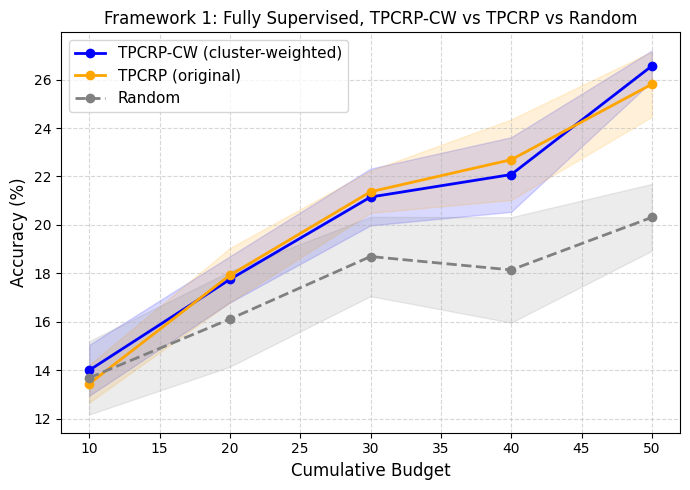

In [13]:
all_cw = np.load('mod_cw_accs.npy')
budgets = [10, 20, 30, 40, 50]

fig, ax = plt.subplots(figsize=(7, 5))
for data, label, color, ls in [
    (all_cw,   'TPCRP-CW (cluster-weighted)', 'blue',   '-'),
    (all_orig, 'TPCRP (original)', 'orange', '-'),
    (all_rand, 'Random', 'gray',   '--'),
]:
    mean = data.mean(axis=0)
    std  = data.std(axis=0)
    ax.plot(budgets, mean, marker='o', color=color,
            linestyle=ls, linewidth=2, label=label)
    ax.fill_between(budgets, mean - std, mean + std,
                    alpha=0.15, color=color)
ax.set_xlabel('Cumulative Budget', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Framework 1: Fully Supervised, TPCRP-CW vs TPCRP vs Random', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('plot_mod_framework1.png', dpi=150)
plt.show()

## Framework 2: Linear Probe on Frozen SimCLR Embeddings - TPCRP-CW

In [10]:
# Load F2 baselines from eval notebook
lp_orig = np.load('tpcrp_lp_accuracies.npy')
lp_rand = np.load('random_lp_accuracies.npy')

# Load or extract test embeddings
if os.path.exists('test_embeddings.npy'):
    test_embeddings = np.load('test_embeddings.npy')
    test_labels_arr = np.load('test_labels.npy')
    print(f"Test embeddings loaded: {test_embeddings.shape}")
else:
    class SimCLR(nn.Module):
        def __init__(self, projection_dim=128):
            super().__init__()
            resnet = models.resnet18(weights=None)
            self.encoder   = nn.Sequential(*list(resnet.children())[:-1])
            self.projector = nn.Sequential(
                nn.Linear(512, 512), nn.ReLU(), nn.Linear(512, projection_dim))
        def forward(self, x):
            h = self.encoder(x).squeeze()
            return h, self.projector(h)

    simclr = SimCLR().to(device)
    simclr.load_state_dict(torch.load('simclr_model.pth', map_location=device))
    simclr.eval()

    basic_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize([0.4914, 0.4822, 0.4465],
                             [0.2023, 0.1994, 0.2010])
    ])
    test_feat_dataset = datasets.CIFAR10(root='./data', train=False,
                                          download=False, transform=basic_transform)
    feat_loader = DataLoader(test_feat_dataset, batch_size=256,
                             shuffle=False, num_workers=2)

    t_embs, t_lbls = [], []
    with torch.no_grad():
        for imgs, targets in tqdm(feat_loader, desc="Extracting test embeddings"):
            h, _ = simclr(imgs.to(device))
            h = nn.functional.normalize(h, dim=1)
            t_embs.append(h.cpu().numpy())
            t_lbls.append(targets.numpy())
    test_embeddings = np.concatenate(t_embs)
    test_labels_arr = np.concatenate(t_lbls)
    np.save('test_embeddings.npy', test_embeddings)
    np.save('test_labels.npy', test_labels_arr)
    print(f"Test embeddings extracted: {test_embeddings.shape}")


def train_linear_probe(labeled_indices, train_embeddings, train_labels,
                       test_embeddings, test_labels_arr, epochs=200):
    X = train_embeddings[labeled_indices]
    y = train_labels[labeled_indices]
    n = len(X)
    batch_size = 32

    probe = nn.Linear(512, 10).to(device)
    optimizer = optim.SGD(probe.parameters(), lr=2.5,
                          momentum=0.9, nesterov=True)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()

    probe.train()
    for epoch in range(epochs):
        perm = np.random.permutation(n)
        for i in range(0, n, batch_size):
            idx = perm[i:i+batch_size]
            xb = torch.tensor(X[idx], dtype=torch.float32).to(device)
            yb = torch.tensor(y[idx], dtype=torch.long).to(device)
            optimizer.zero_grad()
            criterion(probe(xb), yb).backward()
            optimizer.step()
        scheduler.step()

    probe.eval()
    X_test = torch.tensor(test_embeddings, dtype=torch.float32).to(device)
    y_test = torch.tensor(test_labels_arr, dtype=torch.long).to(device)
    with torch.no_grad():
        preds = probe(X_test).argmax(dim=1)
    return 100. * (preds == y_test).float().mean().item()


lp_cw = []

for rep in range(N_REPS):
    print(f"\nLinear Probe Rep {rep+1}/{N_REPS}")
    cw_idx, cw_accs = [], []

    for r in range(5):
        new = tpcrp_cw_select(embeddings, BUDGET,
                              labeled_indices=np.array(cw_idx) if cw_idx else None)
        cw_idx.extend(new.tolist())
        acc = train_linear_probe(cw_idx, embeddings, labels,
                                 test_embeddings, test_labels_arr)
        cw_accs.append(acc)

    lp_cw.append(cw_accs)
    print(f"  TPCRP-CW: {[f'{x:.2f}' for x in cw_accs]}")

lp_cw = np.array(lp_cw)
np.save('mod_lp_cw.npy', lp_cw)
print(f"\nTPCRP-CW mean: {lp_cw.mean(axis=0).round(2)}")
print(f"TPCRP-CW std: {lp_cw.std(axis=0).round(2)}")
print(f"Original mean: {lp_orig.mean(axis=0).round(2)}")
print(f"Random mean: {lp_rand.mean(axis=0).round(2)}")

Test embeddings loaded: (10000, 512)

Linear Probe Rep 1/10
  TPCRP-CW: ['44.54', '58.14', '65.96', '70.30', '71.79']

Linear Probe Rep 2/10
  TPCRP-CW: ['44.60', '58.22', '65.61', '69.59', '71.01']

Linear Probe Rep 3/10
  TPCRP-CW: ['44.64', '57.80', '64.38', '66.65', '68.79']

Linear Probe Rep 4/10
  TPCRP-CW: ['44.67', '58.79', '66.30', '67.16', '70.01']

Linear Probe Rep 5/10
  TPCRP-CW: ['44.71', '58.84', '66.40', '69.28', '71.25']

Linear Probe Rep 6/10
  TPCRP-CW: ['44.61', '60.18', '66.96', '69.68', '70.31']

Linear Probe Rep 7/10
  TPCRP-CW: ['44.31', '57.70', '65.54', '68.10', '69.40']

Linear Probe Rep 8/10
  TPCRP-CW: ['44.62', '58.84', '65.97', '68.86', '70.13']

Linear Probe Rep 9/10
  TPCRP-CW: ['44.60', '63.06', '68.43', '71.01', '71.30']

Linear Probe Rep 10/10
  TPCRP-CW: ['44.71', '58.86', '65.66', '69.65', '70.60']

TPCRP-CW mean: [44.6  59.04 66.12 69.03 70.46]
TPCRP-CW std:  [0.11 1.5  1.   1.3  0.88]
Original mean: [44.74 58.88 65.55 68.45 70.23]
Random mean:   

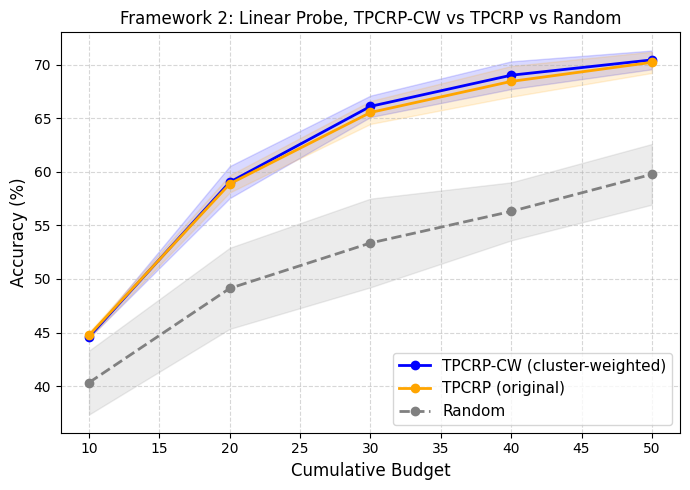

In [12]:
lp_cw = np.load('mod_lp_cw.npy')

fig, ax = plt.subplots(figsize=(7, 5))
for data, label, color, ls in [
    (lp_cw,   'TPCRP-CW (cluster-weighted)', 'blue',   '-'),
    (lp_orig, 'TPCRP (original)', 'orange', '-'),
    (lp_rand, 'Random', 'gray',   '--'),
]:
    mean = data.mean(axis=0)
    std  = data.std(axis=0)
    ax.plot(budgets, mean, marker='o', color=color,
            linestyle=ls, linewidth=2, label=label)
    ax.fill_between(budgets, mean - std, mean + std,
                    alpha=0.15, color=color)
ax.set_xlabel('Cumulative Budget', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Framework 2: Linear Probe, TPCRP-CW vs TPCRP vs Random', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('plot_mod_framework2.png', dpi=150)
plt.show()